# NMR Metabolomics Analysis with NHANES

This notebook follows the structure of the [Nightingale Health NMR Data Analysis Tutorial](https://nightingalehealth.github.io/ggforestplot/articles/nmr-data-analysis-tutorial.html), applying the same analytical approach to publicly available NHANES (National Health and Nutrition Examination Survey) data instead of Nightingale's simulated demo dataset.

**Sections:**
0. Setup
1. Data sources (optional background)
2. Data download & join
3. Exploratory data analysis
4. Preprocessing
5. Linear regression
6. Multiple testing (Benjamini-Hochberg)
7. Forest plot
8. Cox / logistic regression for T2D

## 0. Setup

The following packages are not available on conda-forge and must be installed from CRAN / GitHub on first run. 

In [37]:
#Install the packages
install.packages("remotes")
install.packages("nhanesA")
remotes::install_github("nightingalehealth/ggforestplot")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Using GitHub PAT from the git credential store.

Skipping install of 'ggforestplot' from a github remote, the SHA1 (547617e6) has not changed since last install.
  Use `force = TRUE` to force installation



In [39]:
# Load them in this session
library(tidyverse)
library(nhanesA)
library(ggforestplot)


## 2. Data Download & Join

We use the **2017-2018 NHANES cycle**. Each module is a separate file on the CDC servers; `nhanesA` downloads them directly into R. All modules share a common participant identifier (`SEQN`) which we use to join them into a single dataframe, similarly as joining the NMR results file with the clinical data file in the Nightingale tutorial.

Modules pulled:

| Module | Code | Contains |
|--------|------|----------|
| Demographics | `DEMO_J` | Age, sex, ethnicity |
| Body measures | `BMX_J` | BMI |
| Fasting glucose | `GLU_J` | Plasma glucose |
| HbA1c | `GHB_J` | Glycated haemoglobin |
| Total cholesterol | `TCHOL_J` | Lipids |
| HDL cholesterol | `HDL_J` | Lipids |
| LDL & triglycerides | `TRIGLY_J` | Lipids |
| hsCRP | `HSCRP_J` | Inflammation |
| Diabetes questionnaire | `DIQ_J` | Diabetes status |

In [51]:
# Define variables with the nhanes data from the corresponding modules
demo    <- nhanes("DEMO_J")
bmx     <- nhanes("BMX_J")
glucose <- nhanes("GLU_J")
hba1c   <- nhanes("GHB_J")
tchol   <- nhanes("TCHOL_J")
hdl     <- nhanes("HDL_J")
trigly  <- nhanes("TRIGLY_J")
hscrp   <- nhanes("HSCRP_J")
diq     <- nhanes("DIQ_J")

In [52]:
# Select only the columns we need from each module, then join sequentially on `SEQN`.
df <- demo %>%
  select(SEQN, age = RIDAGEYR, sex = RIAGENDR) %>% # take demo, then select these columns from it, renaming RIDAGEYR to age and RIAGENDR to sex along the way.
  #  for every row in the left table, find the matching row in the right table where SEQN is the same, and attach its columns. If there's no match, fill with NA. 
  left_join(select(bmx,     SEQN, BMI = BMXBMI),             by = "SEQN") %>%
  left_join(select(glucose, SEQN, glucose = LBXGLU),          by = "SEQN") %>%
  left_join(select(hba1c,   SEQN, HbA1c = LBXGH),             by = "SEQN") %>%
  left_join(select(tchol,   SEQN, total_chol = LBXTC),        by = "SEQN") %>%
  left_join(select(hdl,     SEQN, HDL = LBDHDD),              by = "SEQN") %>%
  left_join(select(trigly,  SEQN, LDL = LBDLDL, TG = LBXTR), by = "SEQN") %>%
  left_join(select(hscrp,   SEQN, hsCRP = LBXHSCRP),         by = "SEQN") %>%
  left_join(select(diq,     SEQN, diabetes = DIQ010),         by = "SEQN")

In [53]:
# Check data
dim(df)
head(df)

[1] 9254   12

,SEQN,age,sex,BMI,glucose,HbA1c,total_chol,HDL,LDL,TG,hsCRP,diabetes
,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,93703,2,Female,17.5,NA,NA,NA,NA,NA,NA,NA,No
2,93704,2,Male,15.7,NA,NA,NA,NA,NA,NA,0.29,No
3,93705,66,Female,31.7,NA,6.2,157,60,NA,NA,2.72,No
4,93706,18,Male,21.5,NA,5.2,148,47,NA,NA,0.74,No
5,93707,13,Male,18.1,NA,5.6,189,68,NA,NA,0.32,No
6,93708,66,Female,23.7,122,6.2,209,88,109,58,1.83,Borderline


## 3. Exploratory analyisis

In [43]:
summary(df)

      SEQN             age            sex            BMI           glucose     
 Min.   : 93703   Min.   : 0.00   Male  :4557   Min.   :12.30   Min.   : 47.0  
 1st Qu.: 96016   1st Qu.:11.00   Female:4697   1st Qu.:20.40   1st Qu.: 96.0  
 Median : 98330   Median :31.00                 Median :25.80   Median :102.0  
 Mean   : 98330   Mean   :34.33                 Mean   :26.58   Mean   :111.8  
 3rd Qu.:100643   3rd Qu.:58.00                 3rd Qu.:31.30   3rd Qu.:113.0  
 Max.   :102956   Max.   :80.00                 Max.   :86.20   Max.   :451.0  
                                                NA's   :1249    NA's   :6363   
     HbA1c         total_chol         HDL              LDL       
 Min.   : 3.80   Min.   : 76.0   Min.   : 10.00   Min.   : 18.0  
 1st Qu.: 5.20   1st Qu.:151.0   1st Qu.: 43.00   1st Qu.: 82.0  
 Median : 5.50   Median :176.0   Median : 51.00   Median :103.0  
 Mean   : 5.77   Mean   :179.9   Mean   : 53.39   Mean   :106.9  
 3rd Qu.: 5.90   3rd Qu.:204.0

### Observations

- Biomarkers 'glucose', 'LDL' and 'TG' have ~70% NAs (seems like by design, NHANES only collected fasting measurements from a subsample). Rows with NAs from those biomarkers will be dropped, we will accept a smaller set of participants
- diabetes data will be modified as binary: `Borderline` will be re-classified as 'Yes' and mapped to 1, `No` will be mapped to 0, and `Don't know` rows will be dropped.

## 4. Preprocessing

In [44]:
biomarkers <- c("glucose", "HbA1c", "total_chol", "HDL", "LDL", "TG", "hsCRP")

df_clean <- df %>%
  # recode diabetes outcome
  mutate(diabetes = case_when(
    diabetes == "Yes"        ~ 1,
    diabetes == "Borderline" ~ 1,
    diabetes == "No"         ~ 0,
    TRUE                     ~ NA_real_
  )) %>%
  # drop rows where the outcome is "Don't know" for 'Diabetes'
  drop_na(diabetes) %>%
  # drop rows where any biomarker is missing
  drop_na(glucose, HbA1c, total_chol, HDL, LDL, TG, hsCRP) %>%
  # drop rows where covariates are missing
  drop_na(age, sex, BMI)

dim(df_clean)

[1] 2738   12

In [45]:
# Log-transform and standardise biomarkers (mean 0, SD 1) 
# so that regression estimates are comparable across biomarkers measured on different scales.

df_clean <- df_clean %>%
  mutate(glucose    = log1p(glucose),
         HbA1c      = log1p(HbA1c),
         total_chol = log1p(total_chol),
         HDL        = log1p(HDL),
         LDL        = log1p(LDL),
         TG         = log1p(TG),
         hsCRP      = log1p(hsCRP)) %>%
  mutate(glucose    = as.numeric(scale(glucose)),
         HbA1c      = as.numeric(scale(HbA1c)),
         total_chol = as.numeric(scale(total_chol)),
         HDL        = as.numeric(scale(HDL)),
         LDL        = as.numeric(scale(LDL)),
         TG         = as.numeric(scale(TG)),
         hsCRP      = as.numeric(scale(hsCRP)))

summary(df_clean[, biomarkers])

    glucose            HbA1c           total_chol             HDL          
 Min.   :-3.6987   Min.   :-2.1174   Min.   :-3.758806   Min.   :-5.73415  
 1st Qu.:-0.5335   1st Qu.:-0.6155   1st Qu.:-0.671703   1st Qu.:-0.70620  
 Median :-0.2634   Median :-0.2522   Median : 0.008748   Median :-0.05973  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.000000   Mean   : 0.00000  
 3rd Qu.: 0.1931   3rd Qu.: 0.2071   3rd Qu.: 0.687353   3rd Qu.: 0.62093  
 Max.   : 6.3908   Max.   : 6.7702   Max.   : 4.148557   Max.   : 4.72389  
      LDL                 TG               hsCRP        
 Min.   :-4.98746   Min.   :-3.66483   Min.   :-1.3663  
 1st Qu.:-0.62004   1st Qu.:-0.72777   1st Qu.:-0.7891  
 Median : 0.04807   Median :-0.01148   Median :-0.2418  
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.68619   3rd Qu.: 0.68439   3rd Qu.: 0.5679  
 Max.   : 3.70972   Max.   : 2.68357   Max.   : 4.8422  

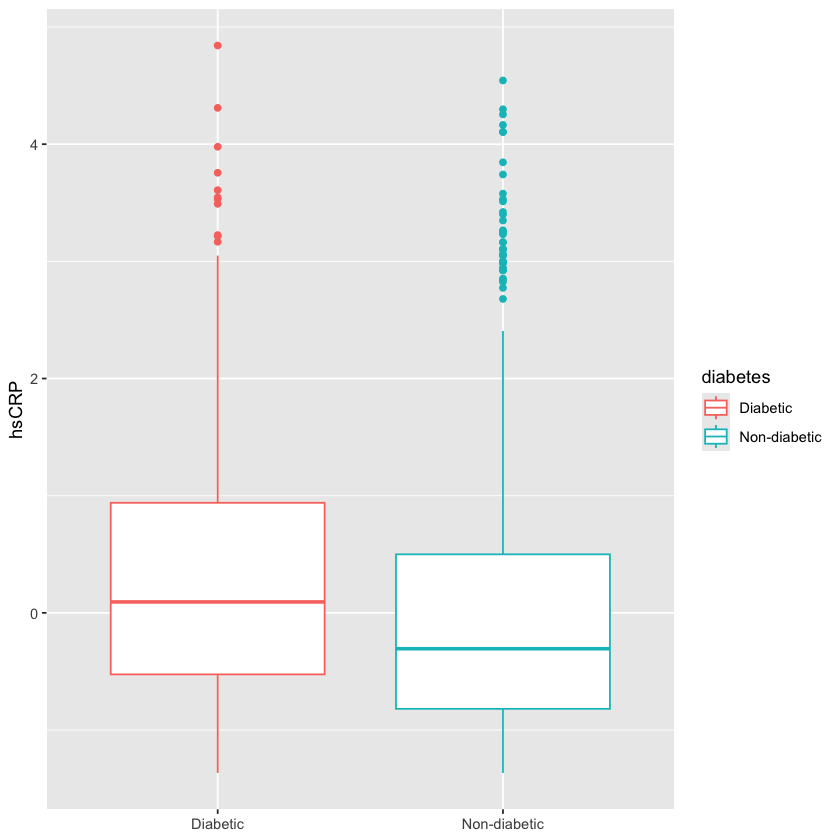

In [46]:
# Before running regressions, we visualise one example: hsCRP (inflammation marker) by diabetes status 
df_clean %>%
  mutate(diabetes = ifelse(diabetes == 1, "Diabetic", "Non-diabetic")) %>%
  ggplot(aes(x = diabetes, y = hsCRP, color = diabetes)) +
  geom_boxplot() +
  theme(axis.title.x = element_blank())

## 5. Linear regression
We run a separate linear regression for each biomarker against BMI, adjusting for age and sex
Just like the Nightingale tutorial. Each model is: `biomarker ~ BMI + age + sex`

The estimate tells us how many SDs does the biomarker change per 1 unit increase in BMI, holding age and sex constant.

In [47]:
# function that runs one linear model for a given biomarker
# and returns the BMI coefficient as a tidy dataframe row
run_lm <- function(biomarker) {
  # build the formula dynamically, e.g. "glucose ~ BMI + age + sex"
  formula <- as.formula(paste(biomarker, "~ BMI + age + sex"))

  # fit the linear model
  model <- lm(formula, data = df_clean)

  # extract model coefficients into a tidy dataframe
  # Filter to keep only the BMI row (we don't care about age/sex coefficients here)
  result <- broom::tidy(model) %>%
    filter(term == "BMI") %>%
    # add a column so we know which biomarker this row refers to
    mutate(biomarker = biomarker)

  return(result)
}

# run the function for every biomarker and stack results into one dataframe
# map_dfr applies run_lm to each element of biomarkers and row-binds the results
df_assoc_bmi <- map_dfr(biomarkers, run_lm) %>%
  select(-term, -statistic)  %>%
  mutate(across(c(estimate, std.error), ~ round(.x, 4)),
         across(c(p.value), ~ signif(.x, 3)))
  
df_assoc_bmi

estimate,std.error,p.value,biomarker
<dbl>,<dbl>,<dbl>,<chr>
0.0272,0.0023,1.83e-30,glucose
0.0254,0.0023,6.84e-28,HbA1c
0.0028,0.0025,2.69e-01,total_chol
-0.0446,0.0023,3.34e-79,HDL
0.0115,0.0025,6.18e-06,LDL
0.0320,0.0024,8.15e-40,TG
0.0637,0.0022,3.69e-161,hsCRP


## 6. Multiple Testing Correction using Benjamini-Hochberg

While the Nightingale tutorial which uses a PCA-based Bonferroni correction, here we use Benjamini-Hochberg (BH).

We ran 7 separate regressions, one per biomarker. Running multiple tests increases the chance of false positives. We BH correction, which controls the False Discovery Rate (FDR): the expected proportion of significant results that are actually false positives.

In [48]:
df_assoc_bmi <- df_assoc_bmi %>%
  # compute BH-adjusted p-values across all 7 biomarker tests
  mutate(p.adjusted = p.adjust(p.value, method = "BH"))

df_assoc_bmi %>%
  select(biomarker, estimate, p.value, p.adjusted)

biomarker,estimate,p.value,p.adjusted
<chr>,<dbl>,<dbl>,<dbl>
glucose,0.0272,1.83e-30,3.202500e-30
HbA1c,0.0254,6.84e-28,9.576000e-28
total_chol,0.0028,2.69e-01,2.690000e-01
HDL,-0.0446,3.34e-79,1.169000e-78
LDL,0.0115,6.18e-06,7.210000e-06
TG,0.0320,8.15e-40,1.901667e-39
hsCRP,0.0637,3.69e-161,2.583000e-160


Observations:
- all biomarkers except `total_chol` show significant association (p<0.05), meaning BMI is associated with most of them.
- glucose, HbA1c, LDL, TG and hsCRP all go up with BMI
- In particular `hsCRP` being the most significant p-value (10^-160) indicates that obesity is strongly inflammatory 
- HDL goes down with BMI, in other words "higher BMI = lower good cholesterol"

## 7. Forest Plot

We visualise the BMI associations for all 7 biomarkers. Each point is the regression estimate (effect size), the horizontal line is the 95% confidence interval, and the dashed vertical line marks zero (no effect). Biomarkers whose confidence interval does not cross zero are significantly associated with BMI.

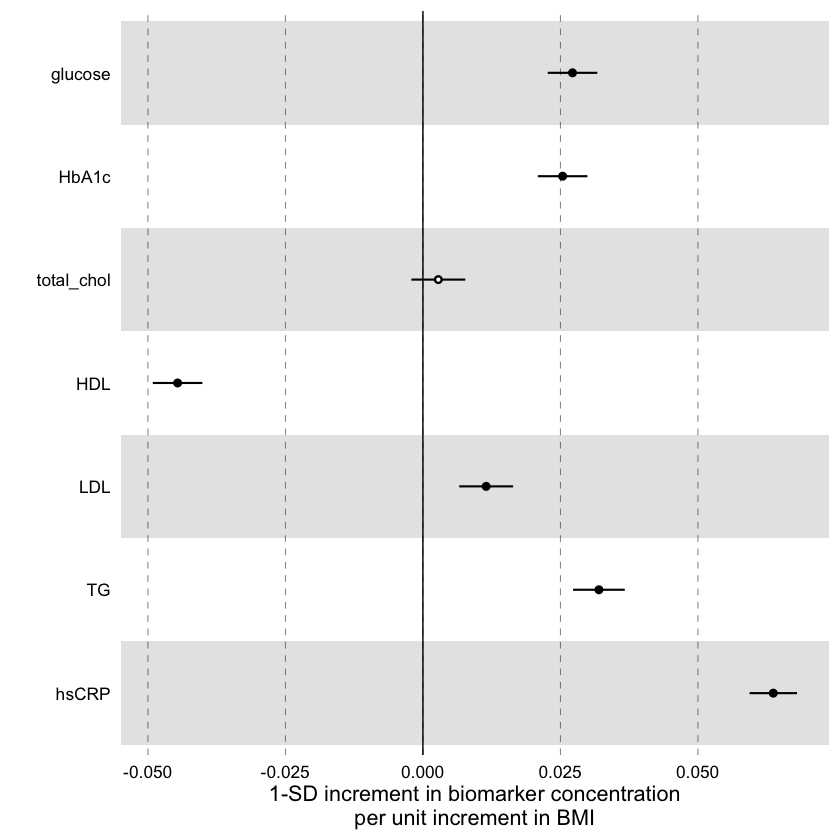

In [49]:
# plot
df_to_plot <- df_assoc_bmi %>%
  # rename columns to match what ggforestplot::forestplot() expects
  rename(name   = biomarker,
         se     = std.error,
         pvalue = p.value)

ggforestplot::forestplot(
  df      = df_to_plot,
  pvalue  = pvalue,
  psignif = 0.05,
  xlab    = "1-SD increment in biomarker concentration\nper unit increment in BMI"
)

## 8. Logistic Regression for Type 2 Diabetes

We now switch outcome from BMI (continuous) to diabetes (binary). Logistic regression models the probability of being diabetic as a function of each biomarker, adjusting for age, sex and BMI.

Each model is: `diabetes ~ biomarker + age + sex + BMI`

In [50]:
# function that runs one logistic regression model for a given biomarker
# and returns the biomarker coefficient as a tidy dataframe row
run_logistic <- function(biomarker) {
  # build the formula dynamically, e.g. "diabetes ~ glucose + age + sex + BMI"
  formula <- as.formula(paste("diabetes ~", biomarker, "+ age + sex + BMI"))

  # fit logistic regression (family = binomial for binary outcome)
  model <- glm(formula, data = df_clean, family = binomial)


  # extract tidy coefficients, keep only the biomarker row
  result <- broom::tidy(model) %>%
    filter(term == biomarker) %>%
    mutate(biomarker = biomarker)

  return(result)
}

# run for every biomarker, drop unnecessary columns, round and stack results
df_assoc_t2d <- df_assoc_t2d %>%
  mutate(across(c(estimate, std.error), ~ round(.x, 4)),
         across(c(p.value), ~ signif(.x, 3)))


df_assoc_t2d

estimate,std.error,p.value,biomarker
<dbl>,<dbl>,<dbl>,<chr>
1.3344,0.0803,5.23e-62,glucose
1.9122,0.1082,6.31e-70,HbA1c
-0.3532,0.0575,8.14e-10,total_chol
-0.4242,0.0641,3.72e-11,HDL
-0.3609,0.0548,4.70e-11,LDL
0.3682,0.0622,3.29e-09,TG
0.0791,0.0604,1.90e-01,hsCRP


## Summary
This notebook applied the Nightingale Health NMR analysis tutorial workflow to NHANES 2017-2018 public data,using Benjamini-Hochberg (BH) correction for multiple testing.

- **7 biomarkers analysed:** glucose, HbA1c, total cholesterol, HDL, LDL, triglycerides, hsCRP
- **Linear regression against BMI:** 6 biomarkers are significantly associated to high BMI, after BH correction
- **HDL uniquely negative:** higher BMI is associated with lower good cholesterol
- **Total cholesterol (`total_chol`) is not significant:** This makes sense, since BMI raises LDL but lowers HDL (and total cholesterol combines HDL and LDL into one number), their opposing associations with BMI cancel each other out
- **hsCRP shows the strongest association:** obesity is strongly inflammatory
- **Section 8** (logistic regression for T2D) to be added
